## Fit the SED of CW CMa

In [1]:
# pylint: disable=invalid-name, no-member, missing-function-docstring, wildcard-import, line-too-long
from pathlib import Path
import warnings
import numpy as np

# pylint: disable=unnecessary-pass
%matplotlib widget
import matplotlib.pyplot as plt
import corner

# pylint: disable=wrong-import-position
warnings.filterwarnings("ignore", "Using UFloat objects with std_dev==0 may give unexpected results.", category=UserWarning)
from uncertainties import ufloat, nominal_value as nom_val
from uncertainties.unumpy import nominal_values as nom_vals
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time

from dust_extinction.parameter_averages import G23

from deblib.vmath import wrap_func_for_uncertainties

from support.extinction import get_gontcharov_av
from support.sed import get_sed_for_target, retain_only_closest_observations
from support.plots import plot_sed, plot_fitted_model
from support.pipeline import deredden, dist_by_brightness_and_teff

from sed_fit.fitter import create_theta, model_func, minimize_fit, mcmc_fit, samples_from_sampler
from sed_fit.stellar_grids import get_stellar_grid

Define the target details. In this case it is CW CMa.

In [2]:
use_quick_mode = True
fit_av = True
NUM_STARS = 2 # Don't change as this only fully supports fitting for 2 right now

target_config = {
    "target": "CW CMa",
    "search_term": "TIC 412254866",
    "source": "Southworth (2026). Tess sector 61 SAP data analysed with JKTEBOP v45.",
    "reference": "WIP",

    # From Table I
    "aka": "TIC 412254866, HD 57802",
    "gaia_dr3_id": 5617822243996018944,
    "spt": "A0V",

    # Mags from SIMBAD
    "mags": {
        "B": ufloat(8.66, 0, "mag(B)"),
        "V": ufloat(8.59, 0, "mag(V)"),
        "G": ufloat(8.539332, 0.002770, "mag(G)"),  # Gaia EDR3
        "J": ufloat(8.370, 0.026, "mag(J)"),        # 2MASS
        "H": ufloat(8.380, 0.042, "mag(H)"),        # 2MASS
        "K": ufloat(8.378, 0.023, "mag(K)"),        # 2MASS
        "obs_time_2mass": Time(2450925.4899, format="jd", scale="utc", location=EarthLocation.of_site("ctio"))
    },

    # Direct from John as E(B-V) = 0.10+/-0.02
    "Av": ufloat(0.10, 0.02) * 3.1,

    # From Gaia DR3
    "ra": 110.46883921803982,                               # deg
    "dec": -23.79370693976778,                              # deg
    "parallax": ufloat(2.9739041865446607, 0.019920485),    # mas
    "ruwe": 0.9705841,

    # From TIC
    "Teff_sys": ufloat(9197.0, 222.3),
    "logg_sys": ufloat(3.9412, 0.0711),

    # From Table II
    "k": ufloat(0.9744, 0.0012),
    "J": ufloat(0.9538, 0.0019),
    "3L": ufloat(0.0294, 0.0011),
    "LR": ufloat(0.847, 0.022),
    "r1": ufloat(0.1663, 0.0009),
    "r2": ufloat(0.1570, 0.0011),

    # From eqn. 1
    "t0": ufloat(2459976.475635, 0.000008),         # BJD_TDB
    "period": ufloat(2.117976124, 0.000000025),     # d

    # From Table V
    "a": ufloat(11.071, 0.040),                     # solRad
    "M1": ufloat(2.087, 0.022),                     # solMass
    "M2": ufloat(1.972, 0.024),                     # solMass
    "R1": ufloat(1.841, 0.012),                     # solRad
    "R2": ufloat(1.738, 0.014),                     # solRad
    "logg1": ufloat(4.227, 0.005),                  # cgs
    "logg2": ufloat(4.253, 0.007),                  # cgs
}

if "dist" not in target_config and "parallax" in target_config:
    target_config["dist"] = 1000 / target_config["parallax"]

In [3]:
theta_plot_labels = np.array([f"$T_{{\\rm eff,{st+1}}} / {{\\rm K}}$" for st in range(NUM_STARS)] \
                            +[f"$\\log{{g}}_{{\\rm {st+1}}}$" for st in range(NUM_STARS)] \
                            +[f"$R_{{\\rm {st+1}}} / {{\\rm R_{{\\odot}}}}$" for st in range(NUM_STARS)] \
                            +["${\\rm dist} / {\\rm pc}$", "${\\rm A_{V}}$"])

theta_keys = np.array([(f"Teff{st+1}", u.K) for st in range(NUM_STARS)] \
                    + [(f"logg{st+1}", u.dex) for st in range(NUM_STARS)] \
                    + [(f"R{st+1}", u.Rsun) for st in range(NUM_STARS)] \
                    + [("dist", u.pc), ("Av", u.dimensionless_unscaled)])

### Fill in any gaps from catalogue lookup

In [4]:
coords = SkyCoord(ra=target_config["ra"] * u.deg, dec=target_config["dec"] * u.deg,
                  distance=nom_val(target_config["dist"]) * u.pc, frame="icrs")
print(f"\n{target_config['target']} SkyCoords are {coords} (or {coords.to_string('hmsdms')})")


CW CMa SkyCoords are <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    (110.46883922, -23.79370694, 336.25831139)> (or 07h21m52.52141233s -23d47m37.34498316s)


### Chose the extinction curve and set up the synthetic model grid
The G23 (Gordon et al., 2023) Milky Way R(V) filter gives us the broadest coverage.

There are BtSettlGrid and KuruczGrid stellar grids available, but the former has broader coverage.

In [5]:
ext_model = G23(Rv=3.1)
model_grid = get_stellar_grid("BtSettlGrid", extinction_model=ext_model,
                              use_quick_mode=use_quick_mode, verbose=True)

Loading model grid from bt-settl-agss.npz created at 2025-11-19 18:41:01.266422+00:00
BtSettlGrid is initializing the fluxes interpolator with a grid of 112 teff, 6 logg & 4 metal values and 5000 wavelength bins...will use slinear interpolation...done.
The use of quick mode requested so will set up pre-filtered fluxes.
Initializing pre-filtered fluxes for 38 filters......................................done.


### Get the SED
The initial call the `get_sed_for_target()` will query the
[VizieR Photometry service](https://vizier.cds.unistra.fr/vizier/sed/doc/). This aggregates and returns
photometric observations from across the platform's many catalogues within a chosen radius of the target.
Once received, the table is pre-processed to ensure consistent units, apply default uncertainties where
missing and to remove duplicate rows.

The call to `retain_only_closest_observations()` then removes all but one observation per filter,
with the closes to the target's coordinates being retained.

Finally, the table is further restricted to remove observations with filters not supported by
the stellar model or any that have been explicitly listed for exclusion.

In [6]:
sed = get_sed_for_target(target_config["target"], target_config["search_term"],
                         radius=0.25, remove_duplicates=True, verbose=True)
sed = retain_only_closest_observations(sed, coords)

# Exclusions for range and filters (either unknown or known & problematic)
model_mask = np.ones((len(sed)), dtype=bool)
model_mask &= model_grid.has_filter(sed["sed_filter"])
model_mask &= np.isin(sed["_tabname"], ["B/denis/denis"], invert="True")
model_mask &= np.isin(sed["sed_filter"], [], invert=True)
model_mask &= (sed["sed_wl"] >= min(model_grid.wavelength_range)) \
            & (sed["sed_wl"] <= max(model_grid.wavelength_range))
sed = sed[model_mask]

print(f"{len(sed)} unique SED observation(s) retained after range & exclusion filtering,",
      "\nand the selection of the 'closest' observation to the target for each Filter.",
      "\nThe units for flux, frequency and wavelength are:",
      ", ".join(f"{sed[f].unit:unicode}" for f in ["sed_flux", "sed_freq", "sed_wl"]))

Opened SED table cw-cma-0.25.vot containing 221 row(s).
Dropped 43 duplicate(s) leaving 178 unique row(s).
31 unique SED observation(s) retained after range & exclusion filtering, 
and the selection of the 'closest' observation to the target for each Filter. 
The units for flux, frequency and wavelength are: W Hz⁻¹ m⁻², Hz, µm


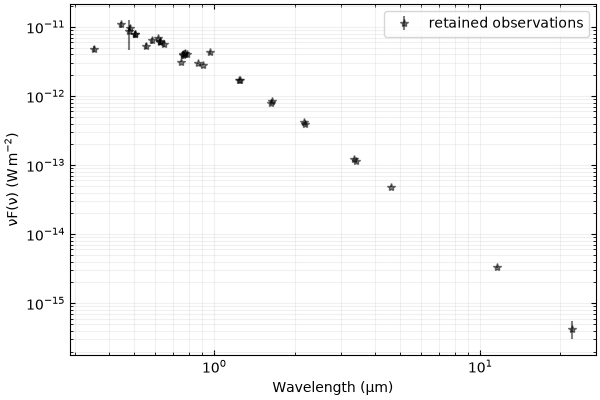

In [7]:
plt.show(plot_sed(x=sed["sed_wl"].quantity,
                  fluxes=[sed["sed_flux"].quantity],
                  flux_errs=[sed["sed_eflux"].quantity],
                  fmts=["*k"],
                  labels=["retained observations"]))

### Get the extinction $A_{\rm V}$ value for the target
We have the option of fitting the extinction value $A_{\rm V}$, or we can de-redden the
observations in advance and fix the fitted extinction at zero. The latter approach is quicker as
the extinction calculations are carried out once only rather than on each fitting iteration.
However, this is no without risk as it assumes the $A_{\rm V}$ is absolutely correct and also
the de-reddening will treat all of flux recorded for each filter as having the same wavelength.

In [8]:
if "Av" in target_config:
    Av = target_config["Av"]
else:
    # Gontcharov has systematic E(B-V) uncert of 0.04 mag
    target_config["Av"] = Av = ufloat(get_gontcharov_av(coords)[0], 0.04 * 3.1)

if fit_av:
    print(f"Av will be fitted (initial Av={Av:.3f}) so observations will not be de-reddened.")
    sed["sed_fit_flux"] = sed["sed_flux"]
else:
    print(f"Will not fit extinction, so dereddening SED observations with Av={nom_val(Av):.3f}")
    sed["sed_fit_flux"] = sed["sed_flux"] / ext_model.extinguish(sed["sed_wl"].to(u.um), Av=nom_val(Av))
    fig = plot_sed(sed["sed_wl"].quantity,
                   fluxes=[sed["sed_flux"].quantity, sed["sed_fit_flux"].quantity],
                   flux_errs=[sed["sed_eflux"].quantity]*2,
                   fmts=["or", ".b"],
                   labels=["observed", f"dereddened\n($A_{{\\rm V}}={Av:.3f})$"],
                   title=target_config["target"] + " SED data")
    plt.show(fig)

Av will be fitted (initial Av=0.310+/-0.062) so observations will not be de-reddened.


### Set up the initial fitting position (theta0)
Set the starting position for fitting based on what we know of the target.

In [9]:
if "TeffR" not in target_config:
    target_config["TeffR"] = (target_config["LR"] / target_config["k"]**2)**0.25

print("System values from lookup and LC fitting:")
for p, unit in [("dist", u.pc), ("Teff_sys", u.K), ("logg_sys", u.dex),
                ("k", None), ("LR", None), ("TeffR", None)]:
    print(f"{p:>12s} = {target_config[p]:12.6f} {unit or u.dimensionless_unscaled:unicode}")

System values from lookup and LC fitting:
        dist =   336.258311+/-    2.252402 pc
    Teff_sys =  9197.000000+/-  222.300000 K
    logg_sys =     3.941200+/-    0.071100 dex
           k =     0.974400+/-    0.001200 
          LR =     0.847000+/-    0.022000 
       TeffR =     0.971857+/-    0.006339 


In [10]:
theta0 = create_theta(teffs=[nom_val(target_config["Teff_sys"])] * NUM_STARS,
                      loggs=[nom_val(target_config[f"logg{i+1}"]) for i in range(NUM_STARS)],
                      radii=[nom_val(target_config[f"R{i+1}"]) for i in range(NUM_STARS)],
                      dist=target_config["dist"].n,
                      av=nom_val(Av) if fit_av else 0,
                      nstars=NUM_STARS,
                      verbose=False)

fit_mask = np.array([True] * NUM_STARS      # Teff
                  + [True] * NUM_STARS      # logg
                  + [True] * NUM_STARS      # radius
                  + [True]                  # dist
                  + [fit_av])               # av

print("\nInitial position, aka theta0. Parameters marked * will be fitted.")
for (param, unit), val, tofit in zip(theta_keys, theta0, fit_mask):
    print(f"{param:>12s}{'*' if tofit else  ' '} = {val:.3f} {unit:unicode}")


Initial position, aka theta0. Parameters marked * will be fitted.
       Teff1* = 9197.000 K
       Teff2* = 9197.000 K
       logg1* = 4.227 dex
       logg2* = 4.253 dex
          R1* = 1.841 R☉
          R2* = 1.738 R☉
        dist* = 336.258 pc
          Av* = 0.310 


### Set up the priors

In [11]:
teff_limits = model_grid.teff_range
logg_limits = model_grid.logg_range
radius_limits = (0.1, 100)
av_limits = (0, 2)

teff_ratio = target_config["TeffR"]
# radius_ratio = target_config["k"]

# Or direct priors for params for which we have known values +/- uncertainties
# teff_priors = [target_config[f"Teff{ix+1}"] for i in range(NUM_STARS)]
logg_priors = [target_config[f"logg{ix+1}"] for ix in range(NUM_STARS)]
radius_priors = [target_config[f"R{ix+1}"] for ix in range(NUM_STARS)]
dist_prior = 1000 / target_config["parallax"]
av_prior = Av

def ln_prior_func(theta: np.ndarray[float]) -> float:
    """
    The fitting prior callback function to evaluate the current set of candidate parameters
    (theta), returning a single negative ln(value) indicating their "goodness".

    Return a negative value as emcee will try to maximize the sum of this and the negative value
    of its ln_prob_func. The fitter component knows to flip the sign if we run a minimize fit.
    """
    teffs = theta[0:2]
    loggs = theta[2:4]
    radii = theta[4:6]
    dist = theta[-2]
    av = theta[-1]

    # Limit criteria checks - hard pass/fail on these
    if not all(teff_limits[0] <= t <= teff_limits[1] for t in teffs):
        return -np.inf
    if not all(logg_limits[0] <= l <= logg_limits[1] for l in loggs):
        return -np.inf
    if not all(radius_limits[0] <= r <= radius_limits[1] for r in radii):
        return -np.inf
    if not av_limits[0] <= av <= av_limits[1]:
        return -np.inf

    # Gaussian prior criteria: g(x) = 1/(σ*sqrt(2*pi)) * exp(-1/2 * (x-µ)^2/σ^2)
    # Omitting scaling expressions and note the implicit ln() cancelling the exp()
    ret_val = 0

    # Gaussian priors based on ratios
    ret_val += ((teffs[1]/teffs[0] - teff_ratio.n) / teff_ratio.s)**2
    # ret_val += ((radii[1]/radii[0] - radius_ratio.n) / radius_ratio.s)**2

    # Gaussian prior based on direct known nom+/-err for these params
    for ix in range(NUM_STARS):
        # ret_val += ((teffs[ix] - teffs_prior[ix].n) / teffs_prior[ix].s)**2
        ret_val += ((loggs[ix] - logg_priors[ix].n) / logg_priors[ix].s)**2
        ret_val += ((radii[ix] - radius_priors[ix].n) / radius_priors[ix].s)**2

    ret_val += ((dist - dist_prior.n) / dist_prior.s)**2
    if fit_av:
        ret_val += ((av - av_prior.n) / av_prior.s)**2
    return -0.5 * ret_val

### Get the observed data to be fitted

In [12]:
# Target flux will be in sed_der_flux even if not yet de-reddened
x = model_grid.get_filter_indices(sed["sed_filter"])
y = (sed["sed_fit_flux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value
y_err = (sed["sed_eflux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value

### Minimize fit and outlier pruning
Minimize fits to do outlier filtering and optionally give a reasonable starting pos for MCMC

In [13]:
theta_min = None
retain_mask = np.ones_like(x, dtype=bool)
min_to_retain, improve_th = int(np.ceil(len(sed) * 0.75)), 0.8

print(f"Outliers will be pruned when doing so improves fit stat > {1-improve_th:.0%}")
cmask, cix, prev_stat = retain_mask.copy(), None, np.inf

for out_ix in range(len(sed)):
    if prev_stat < 1:
        print("Stopped outlier pruning as stat < 1.0")
        break

    ctheta, result = minimize_fit(x[cmask], y[cmask], y_err[cmask], theta0=theta0,
                                  fit_mask=fit_mask, stellar_grid=model_grid,
                                  ln_prior_func=ln_prior_func, methods=["Nelder-Mead"],
                                  verbose=False)
    stat = result.fun
    print(f"[{out_ix:03d}] stat = {stat:.3e}", end="; ")
    if out_ix == 0:
        print("baseline", end="; ")
        theta_min = ctheta

    if (num_retained := sum(cmask)) <= min_to_retain:
        print(f"stopped as SED rows are at or below the minimum of {min_to_retain}")
        break

    if out_ix > 0:
        print(f"candidate {cix}/{sed['sed_filter'][cix]}", end="; ")
        if stat < prev_stat * improve_th:
            print(f"accepted; {sum(cmask)}/{len(cmask)} fluxes remain")
            theta_min, retain_mask = ctheta, cmask.copy()
        else:
            print("rejected for insufficient improvement and now stopping")
            break
    else:
        print()

    # The next candidate mask adds the farthest outlier from this fit.
    y_mdl = model_func(ctheta, x[cmask], model_grid, combine=True)
    cix = cmask.nonzero()[0][np.argmax(((y_mdl - y[cmask]) / y_err[cmask])**2)]
    cmask[cix] = False
    prev_stat = stat

print(f"\nFitted params from {sum(retain_mask)} retained fluxes.",
      "\nThose marked * were fitted. The values in brackets are from the input config.")
for (param, unit), val, fitted in zip(theta_keys, theta_min, fit_mask):
    known = target_config.get(param, np.NaN) if param in target_config else None
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:.3f} {unit:unicode}",
            f"\t ({known:.3f} {unit:unicode})" if known is not None else "")

Outliers will be pruned when doing so improves fit stat > 20%
[000] stat = 7.838e+00; baseline; 
[001] stat = 2.758e+00; candidate 12/PAN-STARRS/PS1:i; accepted; 30/31 fluxes remain
[002] stat = 1.797e+00; candidate 19/PAN-STARRS/PS1:y; accepted; 29/31 fluxes remain
[003] stat = 1.267e+00; candidate 8/PAN-STARRS/PS1:r; accepted; 28/31 fluxes remain
[004] stat = 8.783e-01; candidate 18/SDSS:z; accepted; 27/31 fluxes remain
Stopped outlier pruning as stat < 1.0

Fitted params from 27 retained fluxes. 
Those marked * were fitted. The values in brackets are from the input config.
       Teff1* = 9881.435 K 
       Teff2* = 9603.814 K 
       logg1* = 4.227 dex 	 (4.227+/-0.005 dex)
       logg2* = 4.253 dex 	 (4.253+/-0.007 dex)
          R1* = 1.842 R☉ 	 (1.841+/-0.012 R☉)
          R2* = 1.739 R☉ 	 (1.738+/-0.014 R☉)
        dist* = 336.012 pc 	 (336.258+/-2.252 pc)
          Av* = 0.317  	 (0.310+/-0.062 )


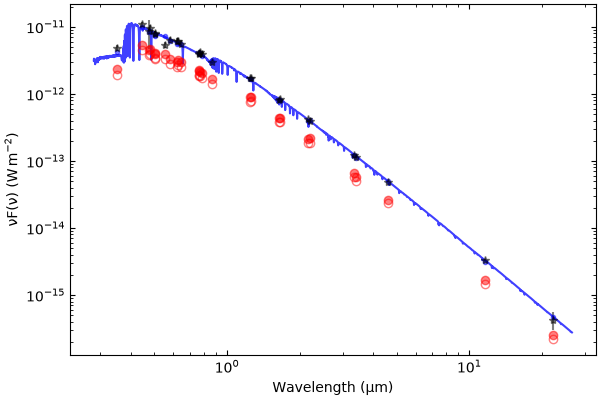

In [14]:
plt.show(plot_fitted_model(sed[retain_mask],
                           theta_min,
                           model_grid,
                           sed_flux_colname="sed_fit_flux",
                           show_component_spectra=False,
                           show_combined_spectrum=True,
                           show_grid=False,
                           show_legend=False))

### MCMC sampling for parameters and uncertainties

In [15]:
thin_by = 10 # sample every nth step from the chain
nwalkers = 100
theta_mcmc, sampler = mcmc_fit(x[retain_mask],
                               y[retain_mask],
                               y_err[retain_mask],
                               theta0=theta0,
                               fit_mask=fit_mask,
                               ln_prior_func=ln_prior_func,
                               stellar_grid=model_grid,
                               nwalkers=nwalkers, nsteps=100000, thin_by=thin_by, processes=8,
                               progress=True, early_stopping=True, early_stopping_from=10000, verbose=True)

mcmc_fit(theta0=[9.197e+03*, 9.197e+03*, 4.227e+00*, 4.253e+00*, 1.841e+00*, 1.738e+00*, 3.363e+02*, 3.100e-01*])
Running MCMC fit on 8 process(es) with 100 walkers for 100000 steps, sampling every 10 steps.
Early stopping is considered after 10000 steps.


 15%|█▌        | 15000/100000 [17:48<1:40:54, 14.04it/s]


Halting MCMC after 15000 steps as the walkers are past 100 times the autocorrelation time & the fit has converged.
Mean Acceptance fraction:    0.456
Autocorrelation steps (tau): 87.642, 88.596, 80.965, 81.972, 82.758, 85.073, 87.073, 82.180
Estimated burn-in steps:     180
Leaving samples of shape:    (148200, 8) *flattened
The MCMC fit yielded theta:  [(9.902+/-0.299)e+03*, (9.623+/-0.290)e+03*, (4.227+/-0.005)e+00*, (4.253+/-0.007)e+00*, (1.842+/-0.012)e+00*, (1.738+/-0.014)e+00*, (3.360+/-0.022)e+02*, (3.206+/-0.588)e-01*]


In [16]:
print(f"Parameters for {target_config['target']} with nominals & 1-sigma uncertainties from MCMC.",
      "\nThose marked * were free. The values in brackets are from the input config.")
for (param, unit), val, fitted in zip(theta_keys, theta_mcmc, fit_mask):
    known = target_config.get(param, np.NaN) if param in target_config else None
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:12.6f} {unit:unicode}",
            f"\t ({known:.6f} {unit:unicode})" if known is not None else "")

Parameters for CW CMa with nominals & 1-sigma uncertainties from MCMC. 
Those marked * were free. The values in brackets are from the input config.
       Teff1* =  9901.505434+/-  298.874934 K 
       Teff2* =  9623.117798+/-  290.458667 K 
       logg1* =     4.227018+/-    0.005007 dex 	 (4.227000+/-0.005000 dex)
       logg2* =     4.252971+/-    0.006985 dex 	 (4.253000+/-0.007000 dex)
          R1* =     1.841512+/-    0.011821 R☉ 	 (1.841000+/-0.012000 R☉)
          R2* =     1.738388+/-    0.013804 R☉ 	 (1.738000+/-0.014000 R☉)
        dist* =   336.049956+/-    2.201590 pc 	 (336.258311+/-2.252402 pc)
          Av* =     0.320562+/-    0.058789  	 (0.310000+/-0.062000 )


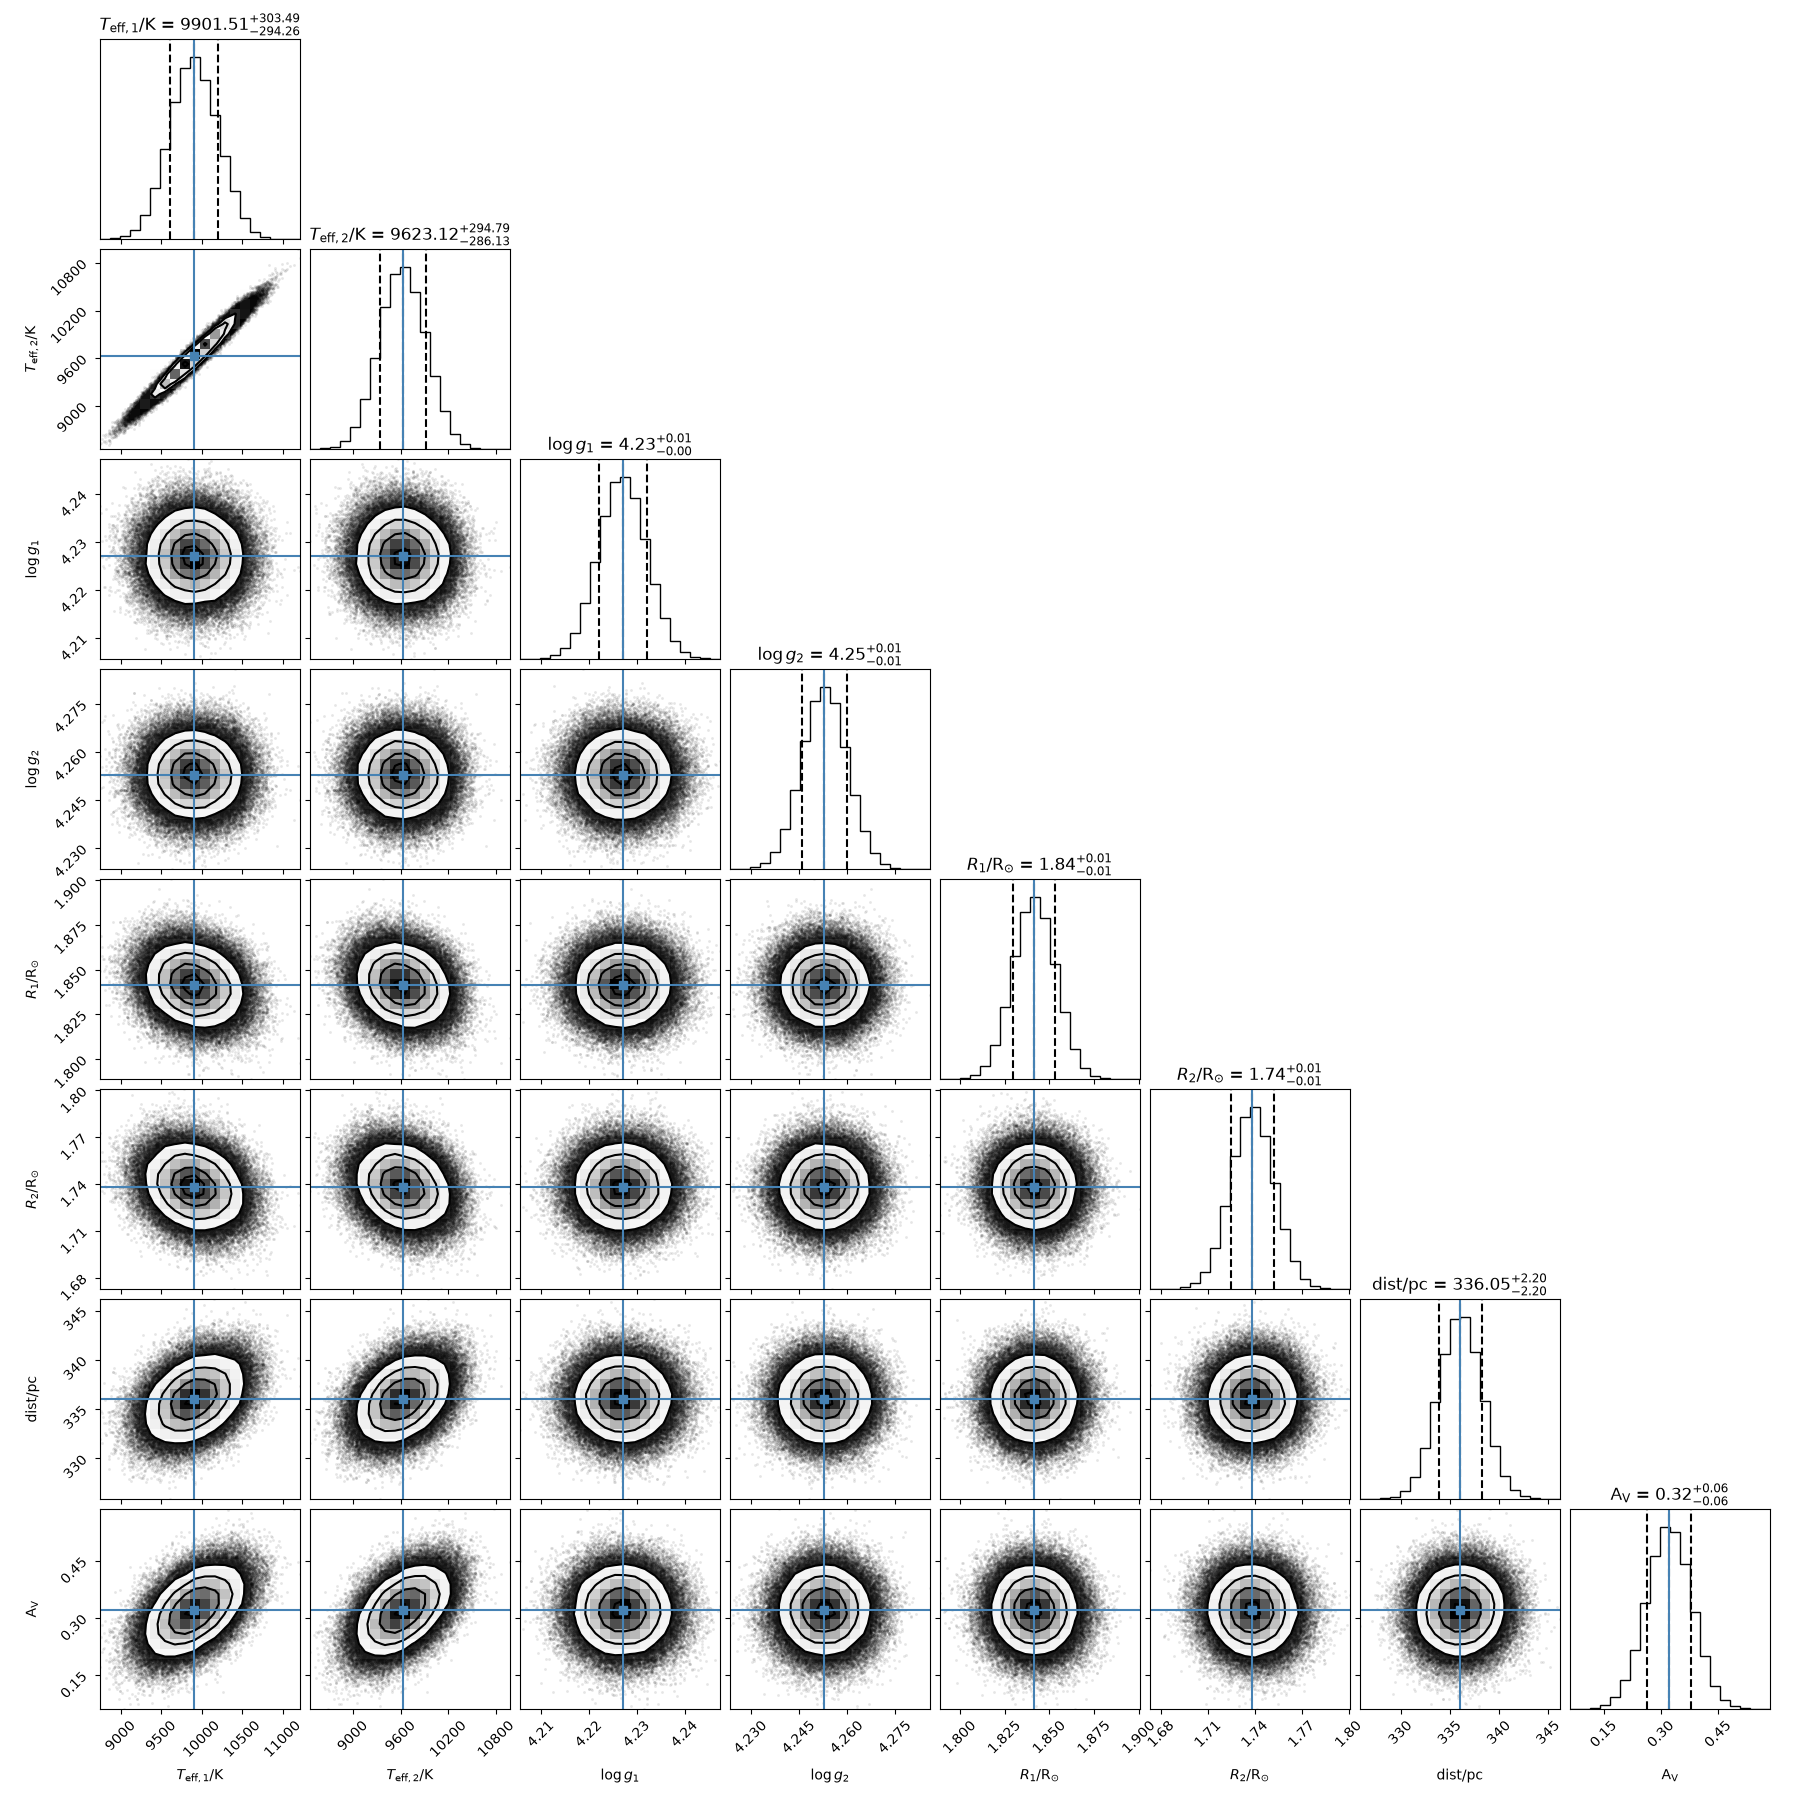

In [17]:
post_burn_samples = samples_from_sampler(sampler, thin_by=thin_by, flat=True)
plt.show(corner.corner(post_burn_samples, show_titles=True, plot_datapoints=True,
                       quantiles=[0.16, 0.5, 0.84], labels=theta_plot_labels[fit_mask],
                       truths=nom_vals(theta_mcmc[fit_mask])))

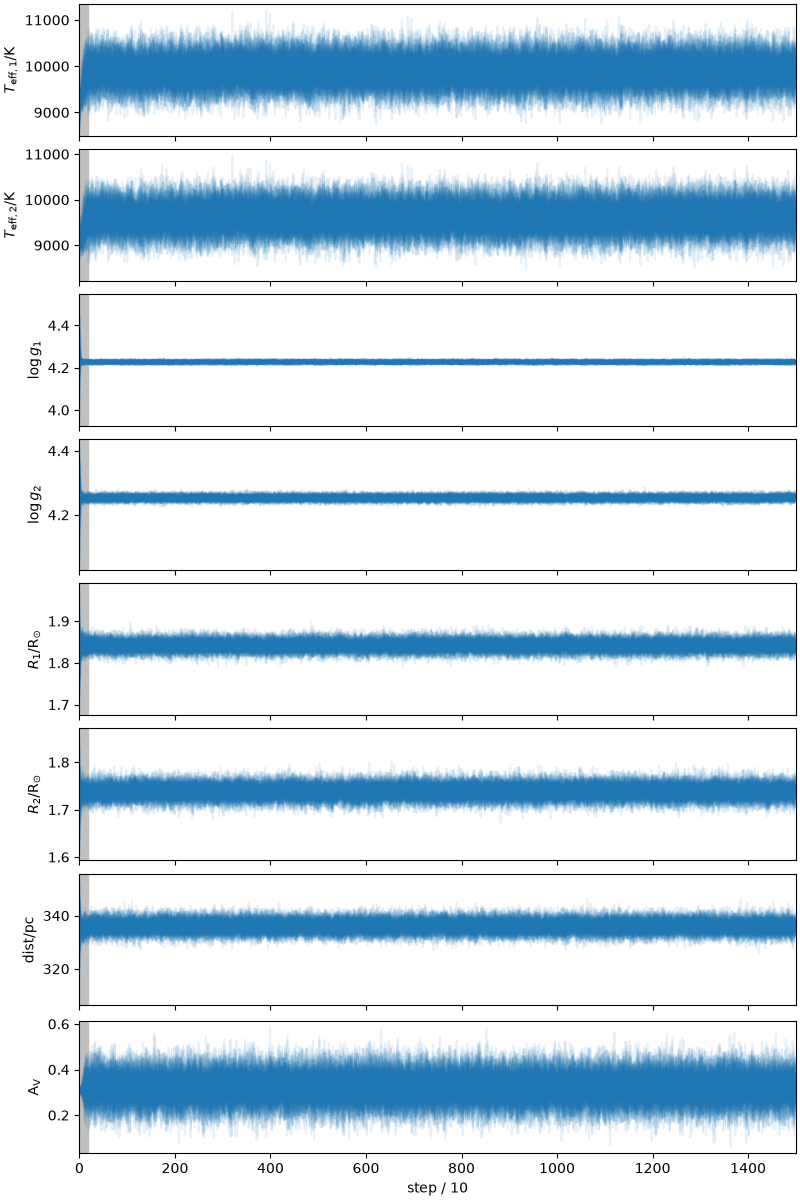

In [18]:
all_samples = sampler.get_chain()
burn_in_samples = all_samples.shape[0] - (post_burn_samples.shape[0] / nwalkers)
fig, axes = plt.subplots(nrows=sum(fit_mask), figsize=(8, 1.5*sum(fit_mask)),
                         sharex=True, constrained_layout=True)
for ix, ax in enumerate(axes.flat):
    ax.plot(all_samples[:, :, ix], "tab:blue", alpha=0.1)
    ax.axvspan(0, burn_in_samples, color="silver")
    ax.set(xlim=(0, len(all_samples)), ylabel=theta_plot_labels[fit_mask][ix])
axes[-1].set(xlabel=f"step / {thin_by}")
plt.show(fig)

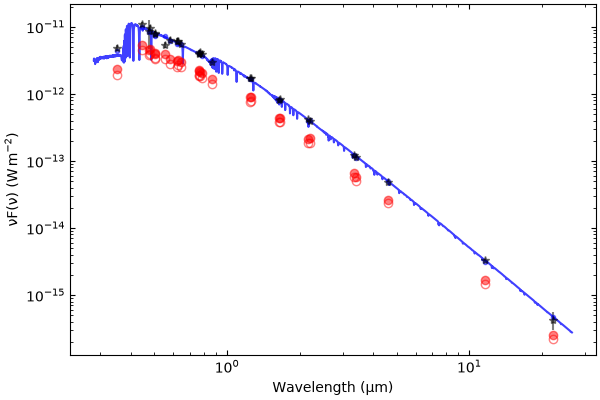

In [19]:
drop_dir = Path("./drop")
drop_dir.mkdir(parents=True, exist_ok=True)

fig = plot_fitted_model(sed[retain_mask], theta_mcmc, model_grid, sed_flux_colname="sed_fit_flux",
                           show_component_spectra=False, show_combined_spectrum=True,
                           show_grid=False, show_legend=False)
fig.savefig(drop_dir / "cw-cma-fitted-sed.pdf", dpi=300)
plt.show(fig)

### Distance calculations
With Kervella+ (2004A&A...426..297K) surface brightness relations

In [20]:
# 2MASS for J, H & K @ JD 2450925.4899 +/- 30 s.
# Quick calculation puts this at approx. phase 0.412 so we will assume outside eclipse.
obs_time_2mass = target_config["mags"]["obs_time_2mass"]
obs_time_2mass_tdb = obs_time_2mass.tdb + obs_time_2mass.light_travel_time(coords)
t0 = Time(nom_val(target_config["t0"]), format="jd", scale="tdb")
phase = (t0 - obs_time_2mass_tdb).to(u.d).value / nom_val(target_config["period"])
phase -= np.floor(phase)
print(f"2MASS J, H & K observations were made at approximate orbital phase {phase:.3f}")

teffs = theta_mcmc[:2]
radii = theta_mcmc[4:6]
dist =  theta_mcmc[6]
av =  theta_mcmc[7]
av.tag = "AV"
ebv = av / 3.1

# These don't naturally support uncertainties UFloats. Instead we calculate uncertainties
# by perturbing the args over the uncertainty range much as the original absdim code does.
wrapped_deredden = wrap_func_for_uncertainties(deredden)
wrapped_kerv = wrap_func_for_uncertainties(dist_by_brightness_and_teff)
for band in ["B", "V", "J", "H", "K"]:
    mag = target_config["mags"][band]
    dmag = wrapped_deredden(ebv=ebv, mag=mag, band=band)

    dist = wrapped_kerv(Teff1=teffs[0], Teff2=teffs[1], R1=radii[0], R2=radii[1], band=band, mag=dmag)
    print(f"dist[mag({band})={mag:.3f}] = {dist:.6f} pc", end="   ")
    print("\t( err contribs:",
          ", ".join(f"{v.tag}={e/dist.s:.3f}" for v, e in dist.error_components().items()), ")")
    
print(f"\ndist[Gaia DR3 parallax] = {target_config['dist']:.6f} pc\t( RUWE={target_config['ruwe']:.3f} )")

2MASS J, H & K observations were made at approximate orbital phase 0.412
dist[mag(B)=8.660+/-0] = 333.228436+/-16.987000 pc   	( err contribs: mag(B)=0.000, AV=0.720, R2=0.070, R1=0.070, Teff2=0.448, Teff1=0.522 )
dist[mag(V)=8.590+/-0] = 335.452903+/-12.828378 pc   	( err contribs: mag(V)=0.000, AV=0.731, R2=0.094, R1=0.092, Teff2=0.444, Teff1=0.501 )
dist[mag(J)=8.370+/-0.026] = 332.591570+/-7.134127 pc   	( err contribs: mag(J)=0.558, AV=0.407, R2=0.171, R1=0.161, Teff2=0.454, Teff1=0.511 )
dist[mag(H)=8.380+/-0.042] = 333.470353+/-7.197547 pc   	( err contribs: mag(H)=0.896, AV=0.243, R2=0.172, R1=0.158, Teff2=0.201, Teff1=0.208 )
dist[mag(K)=8.378+/-0.023] = 335.136323+/-4.780019 pc   	( err contribs: mag(K)=0.743, AV=0.306, R2=0.260, R1=0.240, Teff2=0.327, Teff1=0.350 )

dist[Gaia DR3 parallax] = 336.258311+/-2.252402 pc	( RUWE=0.971 )
